
# 00 — Data audit

What the two traces actually are, and the three measurement errors that shaped the
earlier results. Nothing here is modelling; it is all things that can be checked
directly against the CSVs.

The three findings, in order of how much they matter:

1. **Neither trace is hourly.** GP samples every ~86 min and Robi every ~99 min, so
   `lag_24` spans 34.4 h and 39.6 h — roughly anti-phase to the daily cycle.
2. **The rolling features leaked the target.** Windows were computed without a shift,
   putting `y_t` inside its own feature vector.
3. **The context flags act on variance, not level.** Most do not predict how much
   demand there will be; `is_rain` predicts how *wrong* the forecast will be.

In [1]:
# --- Bootstrap: works locally and on Colab ---------------------------------
# Locally this just finds the repository root. On Colab the repo is not on the VM
# yet, so it is cloned first. The repository is PRIVATE, which means the clone
# needs a GitHub token -- put one in Colab Secrets (the key icon in the left
# sidebar) under the name GH_TOKEN and enable notebook access. See docs/COLAB.md.
import os, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = "github.com/sad-code-at/bwalloc.git"

ROOT = Path.cwd()
while not (ROOT / "src" / "bwalloc").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "src" / "bwalloc").exists():
    target = Path("/content/bwalloc")
    if not (target / "src" / "bwalloc").exists():
        try:
            from google.colab import userdata
            token = userdata.get("GH_TOKEN")
        except Exception:
            token = None
        if not token:
            raise SystemExit(
                "Could not find the repository, and no GH_TOKEN is available. "
                "On Colab: add a GitHub token in Secrets (the key icon) as "
                "GH_TOKEN, enable notebook access for this notebook, and re-run "
                "-- see docs/COLAB.md. Locally: run this notebook from inside "
                "the repository."
            )
        # The token never reaches stdout: git is quiet and errors are sanitised.
        rc = os.system(f"git clone -q https://{token}@{REPO} {target} 2>/dev/null")
        if rc != 0 or not (target / "src" / "bwalloc").exists():
            raise SystemExit(
                "git clone failed. Check that GH_TOKEN is valid, not expired, and "
                "has read access to this repository (Contents: Read)."
            )
    os.chdir(target)
    ROOT = target

sys.path.insert(0, str(ROOT / "src"))

try:
    import xgboost  # noqa: F401
except ImportError:
    !pip install -q xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import bwalloc as bw
from bwalloc.plots import use_paper_style

bw.set_seed()
use_paper_style()
pd.set_option("display.width", 200)
RESULTS = ROOT / "experiments" / "results"
# Scratch output for the exploratory notebooks. Only 07_paper_figures writes into
# paper/figures -- otherwise running notebook 00 or 05 silently overwrites a figure
# the paper cites, which is exactly the kind of drift this project exists to remove.
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
print("bwalloc", bw.__version__, "| results:", RESULTS)

bwalloc 0.1.0 | results: D:\L4-T-1\EEE 402\project\bwalloc\experiments\results


## Sampling rate

Every seasonal hyperparameter in this project is derived from this table. Nothing is hardcoded to 24.

In [2]:

from bwalloc.data import TARGET, load, sampling_profile, autocorrelation_by_lag

traces = {}
for operator in ("gp", "robi"):
    df = load(operator)
    profile = sampling_profile(df)
    traces[operator] = (df, profile)
    print(f"{operator.upper():5} {profile.describe()}")
    print(f"      lag 24 samples spans {profile.hours_for_lag(24):.1f} h "
          f"— the original code called this 'one day'")
    print(f"      one day is actually {profile.lag_for_hours(24)} samples\n")

GP    n=905, span=54.2 d, median gap=86.0 min (16.74 samples/day), daily period ~= 17 samples [lag 24 spans 34.4 h]
      lag 24 samples spans 34.4 h — the original code called this 'one day'
      one day is actually 17 samples

ROBI  n=888, span=60.9 d, median gap=99.0 min (14.55 samples/day), daily period ~= 15 samples [lag 24 spans 39.6 h]
      lag 24 samples spans 39.6 h — the original code called this 'one day'
      one day is actually 15 samples



## Autocorrelation: the lag the original models used is negatively correlated

This is the whole sampling-rate argument in one figure. The measured daily period has strong positive autocorrelation; lag 24 has negative.

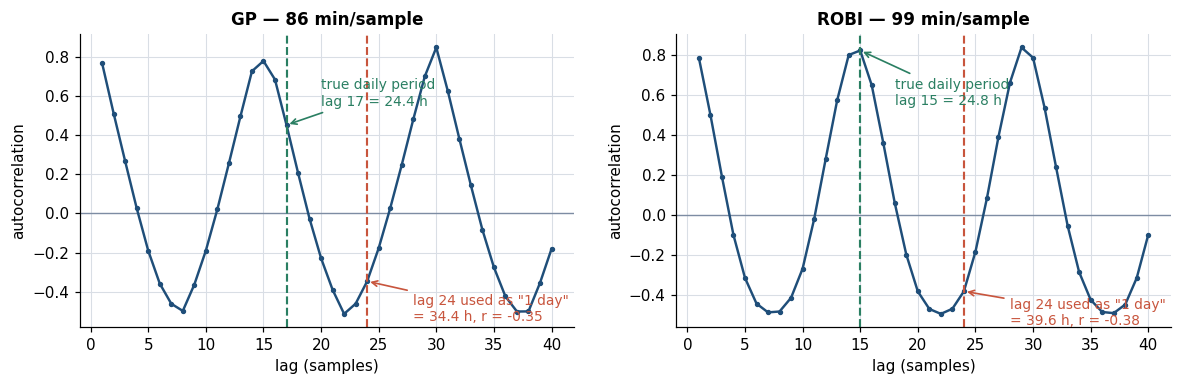

In [3]:

from bwalloc.plots import plot_autocorrelation_by_lag

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (operator, (df, profile)) in zip(axes, traces.items()):
    acf = autocorrelation_by_lag(df[TARGET], max_lag=40, profile=profile)
    plot_autocorrelation_by_lag(acf, profile, ax=ax)
    ax.set_title(f"{operator.upper()} — {profile.median_gap_min:.0f} min/sample")
fig.tight_layout()
fig.savefig(FIGURES / "fig1_autocorrelation.png", dpi=200, bbox_inches="tight")

## The empirical consequence

A seasonal-naive forecaster at the measured period against the same forecaster at lag 24. Same data, same code, one hyperparameter.

In [4]:

from bwalloc.metrics import rmse

rows = []
for operator, (df, profile) in traces.items():
    y = df["Gbps"]
    for lag, label in ((profile.daily_period, "measured daily period"), (24, "lag 24")):
        rows.append({
            "operator": operator, "lag": lag, "spans_hours": round(profile.hours_for_lag(lag), 1),
            "label": label, "rmse": rmse(y.iloc[lag:], y.shift(lag).dropna()),
        })
pd.DataFrame(rows)

,operator,lag,spans_hours,label,rmse
0,gp,17,24.4,measured daily period,18.163525
1,gp,24,34.4,lag 24,28.415589
2,robi,15,24.8,measured daily period,26.584180
3,robi,24,39.6,lag 24,74.115838


## Target leakage

`assert_no_leakage` perturbs the final target value and asserts no feature column moves. The corrected builder passes; a builder with an unshifted rolling window would not.

In [5]:

from bwalloc.features import FeatureConfig, assert_no_leakage, build_features

for operator, (df, profile) in traces.items():
    assert_no_leakage(df, profile, FeatureConfig())
    X, y = build_features(df, profile, FeatureConfig())
    print(f"{operator.upper():5} leak-free — {X.shape[1]} features, {len(X)} usable rows")

GP    leak-free — 25 features, 888 usable rows
ROBI  leak-free — 21 features, 873 usable rows


## Context flags — the dataset's distinctive asset, tested for the first time

Welch t-test on the level, Levene's test on the spread of hour-detrended residuals. The variance column is the one that matters: it is what the context-conditional method in notebook 03 is built on.

In [6]:

from bwalloc.context import flag_report, group_sizes, assign_binary_groups

for operator, (df, profile) in traces.items():
    print(f"=== {operator.upper()} ===")
    report = flag_report(df, operator)
    display(report)
    print(group_sizes(assign_binary_groups(df)).to_string(index=False), "\n")

=== GP ===


,flag,n_on,mean_on,mean_off,delta_mean,p_level,resid_sd_on,resid_sd_off,variance_ratio,p_variance
0,is_rain,131,96.724452,92.224723,4.499729,0.026156,21.798582,16.384587,1.330432,4.693899e-07
1,is_political_gathering,101,95.263494,92.576151,2.687343,0.166435,18.360115,17.188199,1.068181,2.597358e-01
2,is_powercut,118,90.586659,93.219330,-2.632671,0.130430,17.669598,17.265364,1.023413,8.322132e-01
3,is_event,275,92.715308,92.946237,-0.230929,0.855561,17.544381,17.251475,1.016979,5.709269e-01
4,is_drama,147,91.600614,93.123415,-1.522800,0.336682,17.363643,17.326340,1.002153,7.697360e-01
5,is_weekend,261,93.137807,92.769986,0.367821,0.769860,16.861666,17.530459,0.961850,9.399420e-01
6,is_holiday,49,89.105991,93.091875,-3.985884,0.110991,16.361893,17.369551,0.941987,3.860969e-01
7,is_offer,235,88.633356,94.364179,-5.730823,0.000005,15.857720,17.589059,0.901567,1.330046e-02
8,event,13,102.099256,92.741646,9.357609,0.026972,13.421753,17.352197,0.773490,9.424338e-02


        group  n_rows  approx_calib  max_supported_tau
     baseline     706           176               0.99
elevated_risk     199            50               0.98 

=== ROBI ===


,flag,n_on,mean_on,mean_off,delta_mean,p_level,resid_sd_on,resid_sd_off,variance_ratio,p_variance
0,is_holiday,14,149.222857,145.479405,3.743452,0.758637,31.784638,30.142812,1.054468,9.568569e-01
1,is_political_gathering,89,141.773933,145.957747,-4.183815,0.423148,30.026222,30.147967,0.995962,3.012550e-01
2,is_weekend,263,144.425399,146.006784,-1.581385,0.639710,29.302475,30.513810,0.960302,5.174728e-01
3,is_powercut,101,136.408713,146.710089,-10.301376,0.023359,22.834304,30.797302,0.741438,4.455604e-04
4,is_event,234,145.294017,145.625872,-0.331854,0.917525,22.935331,32.363214,0.708685,2.110857e-08


        group  n_rows  approx_calib  max_supported_tau
     baseline     799           200               0.99
elevated_risk      89            22               0.95 




### Reading the table

Two things fall out, and both are used later:

- **`is_weekend` carries no signal at all** on the level (p = 0.77) — yet it is in
  every feature list, and *both source filenames advertise it*. Six of the nine flags
  are indistinguishable from noise on the mean.
- **`is_rain` raises residual σ from 16.4 to 21.8 Gbps — a 33% increase in
  uncertainty** — while moving the mean only modestly.

Context here acts on the **variance**, not the level. A point forecaster with a
context dummy cannot express that. A context-conditional *interval* can, and that is
notebook 03.